# Parameters

In [1]:
from common.utils import (
    omega_c,
    default_three_phase_protocol,
)

from pathlib import Path
import numpy as np

%load_ext autoreload
%autoreload 2

N = 20
gamma = 1.0
Omega_ratio = 0.4
delta0 = 1.0

N_J = N // 2
Omega0 = Omega_ratio * omega_c(N_J, gamma)

# Define the three-phase protocol with the desired parameters.
phases = default_three_phase_protocol(
    T1=10.0,
    T2=10.0,
    T3=10.0,
    delta0=delta0,
    Omega0=Omega0,
)

seed = 1234
dt = 1e-1
save_every = 10

### Custom Quantum Trajectory - Single

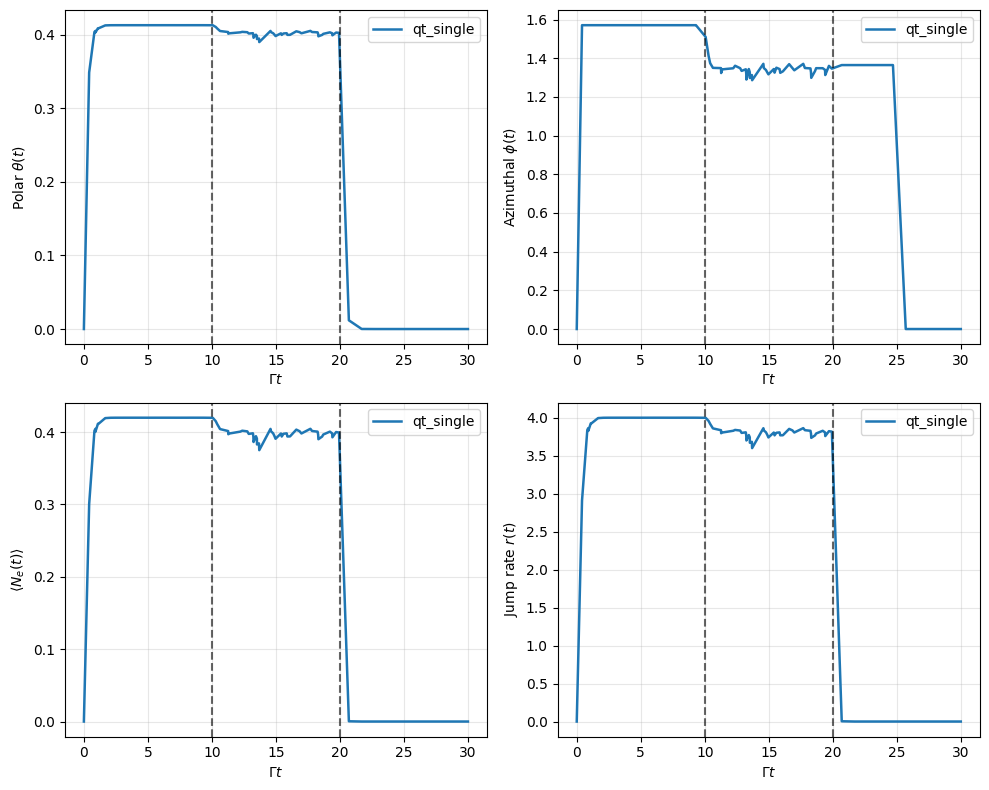

In [2]:
def run_single_trajectory(shifted_jump_operator=False):
    from quantum_trajectories.state_helpers import centered_sector_initial_coeffs
    from quantum_trajectories.sim import simulate_single_trajectory
    from common.plotting import plot_trajectory_angles_and_excitation
    from quantum_trajectories.aggregator import (
        trajectory_observables,
        single_trajectory_to_averaged_result,
    )

    # Returns a dictionary of key: sector Nj, value: coefficient for that sector. 
    sector_coeffs = centered_sector_initial_coeffs(N, half_width=0)

    # Simulate a single trajectory
    result = simulate_single_trajectory(
        N=N,
        gamma=gamma,
        phases=phases,
        sector_coeffs=sector_coeffs,
        dt=dt,
        save_every=save_every,
        seed=seed,
        shifted_jump_operator=shifted_jump_operator,
    )

    obs = trajectory_observables(result)
    obs = single_trajectory_to_averaged_result(result, obs)


    # fig, axes = plot_trajectory_angles_and_excitation(result, phases)
    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)
    fig, axes = plot_trajectory_angles_and_excitation(
        obs,
        phases,
        output_path=output_dir / "qt_single.png",
        label="qt_single",
    )

run_single_trajectory(shifted_jump_operator = False)

### Custom Quantum Trajcetory - Ensamble

simulation runtime: 10.101 s


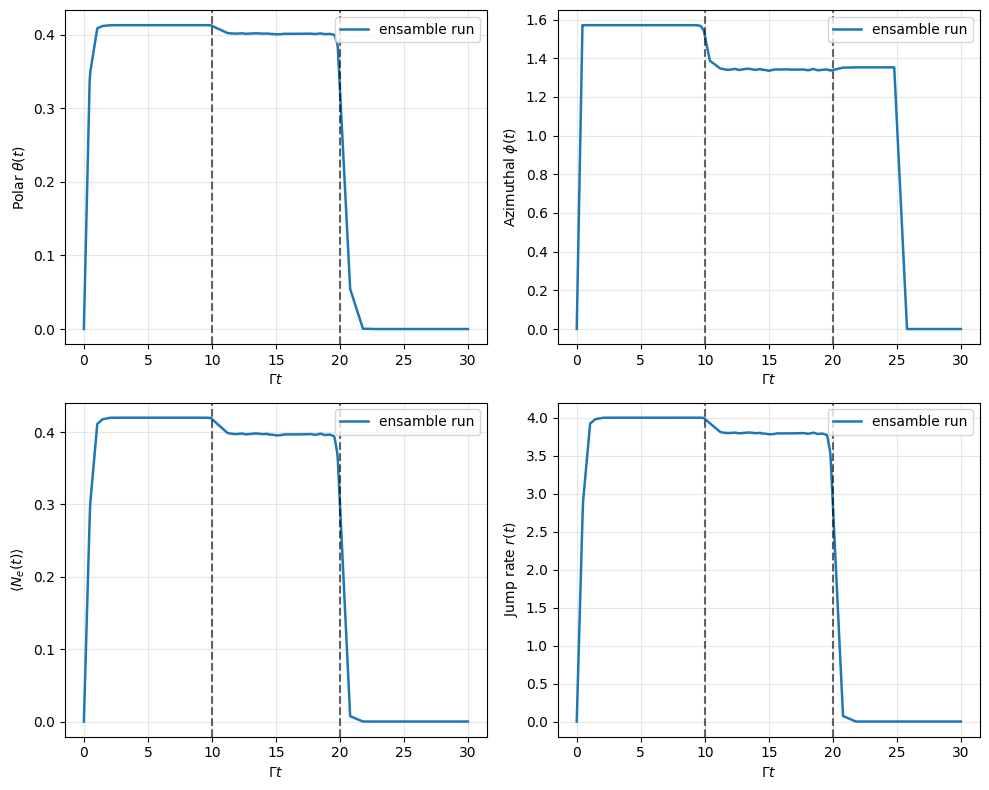

In [3]:
def run_ensamble(shifted_jump_operator=False):
    import time

    from quantum_trajectories.state_helpers import centered_sector_initial_coeffs
    from quantum_trajectories.ensamble_sim import run_trajectory_ensemble
    from quantum_trajectories.aggregator import (
        ensemble_observables,
        make_averaged_result
    )
    from common.plotting import plot_trajectory_angles_and_excitation

    sector_coeffs = centered_sector_initial_coeffs(N, half_width=0)

    t0 = time.perf_counter()
    ensemble = run_trajectory_ensemble(
        N=N,
        gamma=gamma,
        phases=phases,
        sector_coeffs=sector_coeffs,
        dt=dt,
        save_every=save_every,
        seed=seed,
        ntraj=100,
        shifted_jump_operator=shifted_jump_operator,
    )
    simulation_runtime = time.perf_counter() - t0

    obs_avg = ensemble_observables(ensemble)
    avg_result = make_averaged_result(ensemble, obs_avg)

    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)
    fig, axes = plot_trajectory_angles_and_excitation(
        avg_result,
        phases,
        output_path=output_dir / "qt_ensable.png",
        show_spread=False,
        label=f"ensamble run"
    )

    print(f"simulation runtime: {simulation_runtime:.3f} s")

run_ensamble(shifted_jump_operator = False)


### Custom Quantum Trajectory - Ensamble - half_width time scaling

/Users/ashar/.pyenv/versions/cavity-OAT_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
half_width sweep:   8%|▊         | 4/51 [00:01<00:15,  3.02it/s]/Users/ashar/.pyenv/versions/cavity-OAT_env/lib/python3.12/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
half_width sweep: 100%|██████████| 51/51 [00:33<00:00,  1.54it/s]


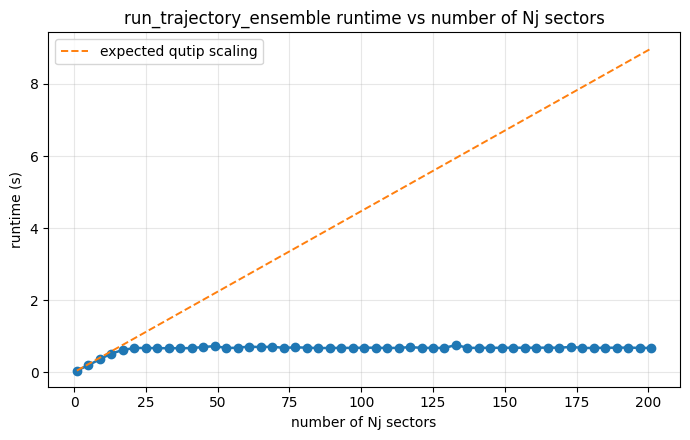

In [4]:
def run_ensamble_half_width_time_scaling(max_half_width, shifted_jump_operator=False):
    import time
    import matplotlib.pyplot as plt
    from tqdm.auto import tqdm

    from quantum_trajectories.state_helpers import centered_sector_initial_coeffs
    from quantum_trajectories.ensamble_sim import run_trajectory_ensemble

    half_width_values = list(range(0, max_half_width + 1, 2))
    num_nj_sectors = [2 * half_width + 1 for half_width in half_width_values]
    half_width_runtimes = []

    for half_width in tqdm(half_width_values, desc="half_width sweep"):
        sector_coeffs = centered_sector_initial_coeffs(N, half_width=half_width)

        t0 = time.perf_counter()
        _ = run_trajectory_ensemble(
            N=N,
            gamma=gamma,
            phases=phases,
            sector_coeffs=sector_coeffs,
            dt=dt,
            save_every=save_every,
            seed=seed,
            ntraj=10,
            shifted_jump_operator=shifted_jump_operator,
        )
        runtime = time.perf_counter() - t0
        half_width_runtimes.append(runtime)
        # print(f"half_width={half_width}: {runtime:.3f} s")

    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(num_nj_sectors, half_width_runtimes, marker="o", linewidth=1.8)
    baseline_runtime = half_width_runtimes[0]
    reference_curve = [baseline_runtime * x for x in num_nj_sectors]
    ax.plot(num_nj_sectors, reference_curve, "--", linewidth=1.4, label="expected qutip scaling")
    ax.set_xlabel("number of Nj sectors")
    ax.set_ylabel("runtime (s)")
    ax.set_title("run_trajectory_ensemble runtime vs number of Nj sectors")
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / "qt_ensamble_half_width_time_scaling.png", dpi=200, bbox_inches="tight")

    # half_width_runtimes

run_ensamble_half_width_time_scaling(max_half_width=100, shifted_jump_operator=True)

### Qutip Monte Carlo Solver

/Users/ashar/Documents/Github/cavity-OAT/quantum_trajectories_qutip/sim.py:214: SyntaxWarning: invalid escape sequence '\d'
  """


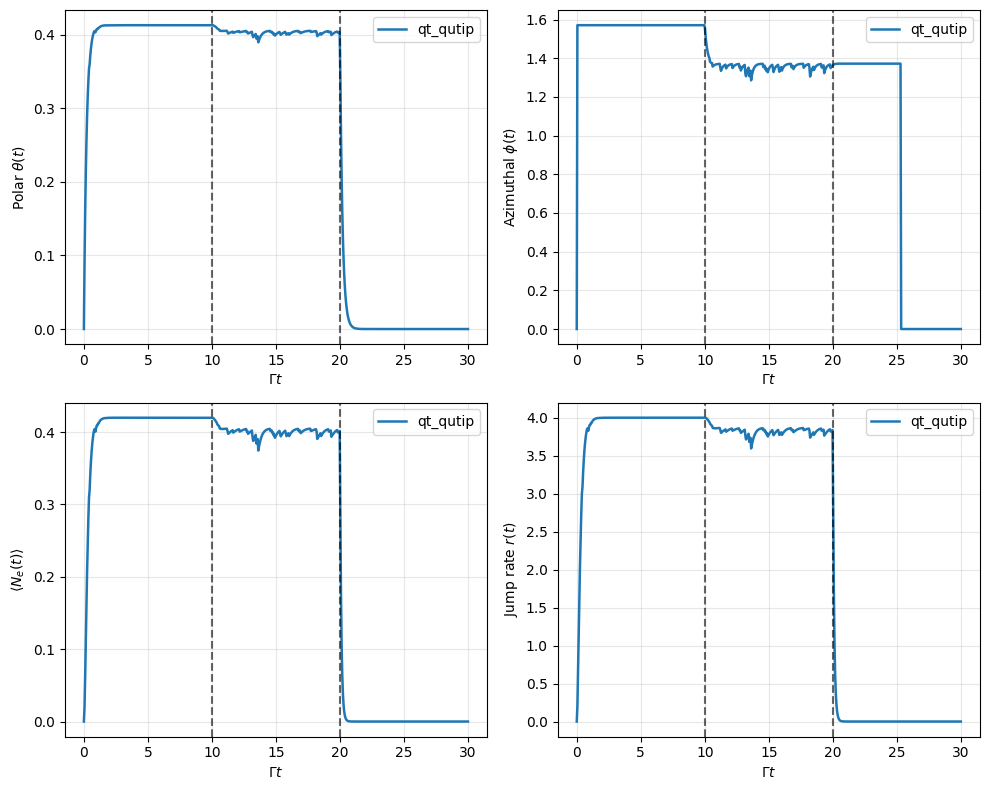

In [5]:
def run_qutip_mcsolve(shifted_jump_operator=False):
    from quantum_trajectories_qutip.sim import (
        simulate_fixed_nj_mc_trajectory
    )
    from quantum_trajectories_qutip.aggregator import qutip_fixed_nj_mcsolve_observables
    from common.plotting import plot_trajectory_angles_and_excitation


    qt_sim = simulate_fixed_nj_mc_trajectory(
        N=N,
        gamma=gamma,
        phases=phases,
        num_points=600,
        ntraj=1,
        seed=1234,
        shifted_jump_operator=shifted_jump_operator,
    )

    obs_qutip = qutip_fixed_nj_mcsolve_observables(qt_sim)

    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)
    fig, axes = plot_trajectory_angles_and_excitation(
        obs_qutip,
        phases,
        output_path=output_dir / "qt_qutip.png",
        axes=None,
        label="qt_qutip",

    )

run_qutip_mcsolve(shifted_jump_operator = False)

### Qutip Master Equation Solver

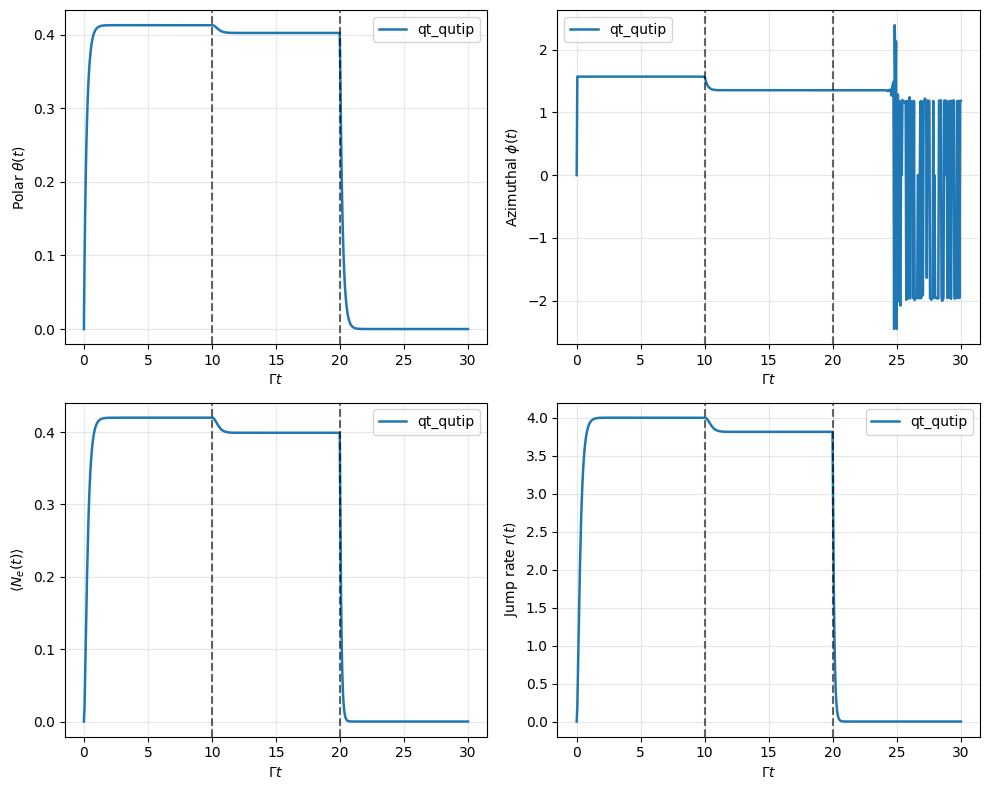

In [6]:
def run_qutip_mesolve(shifted_jump_operator=False):
    from quantum_trajectories_qutip.sim import simulate_fixed_nj_me_trajectory
    from quantum_trajectories_qutip.aggregator import qutip_fixed_nj_mcsolve_observables
    from common.plotting import plot_trajectory_angles_and_excitation


    me_res = simulate_fixed_nj_me_trajectory(
        N=N,
        gamma=gamma,
        phases=phases,
        num_points=600,
        shifted_jump_operator=shifted_jump_operator,
    )

    me_obs = qutip_fixed_nj_mcsolve_observables(me_res)

    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)
    fig, axes = plot_trajectory_angles_and_excitation(
        me_obs,
        phases,
        output_path=output_dir / "qt_qutip.png",
        axes=None,
        label="qt_qutip",

    )

run_qutip_mesolve(shifted_jump_operator = False)

##### Single Quantum Trajectories - Custom vs Qutip

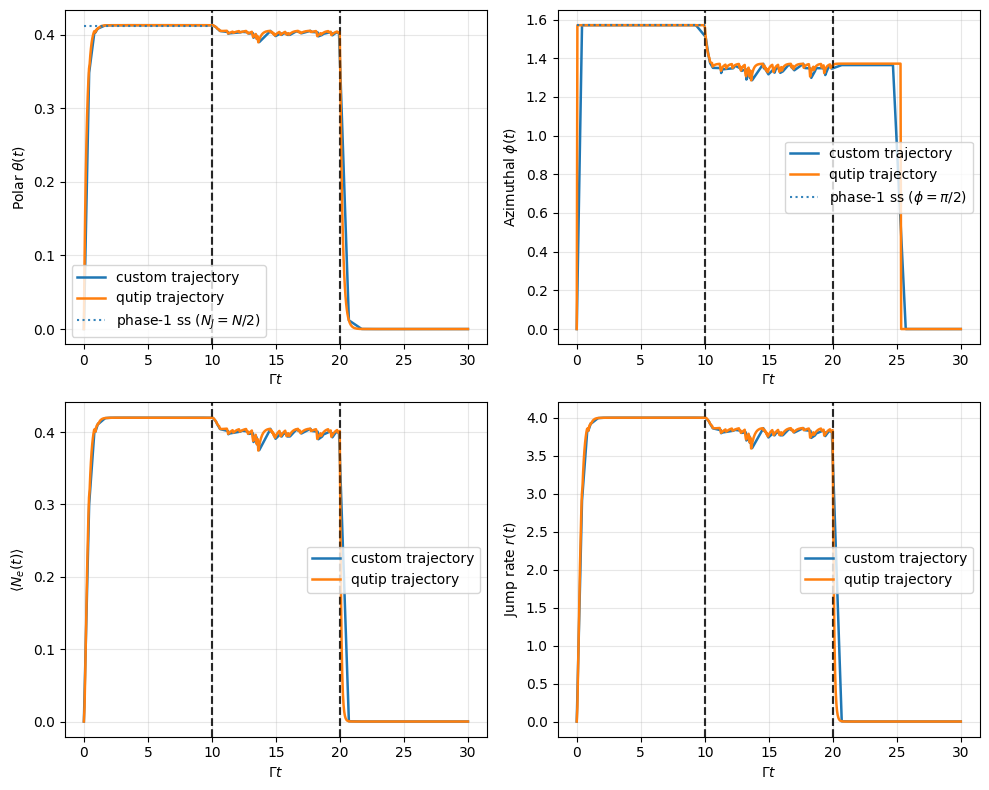

In [7]:
def mcsolve_v_custom_trajectory(print_numerics = False, shifted_jump_operator=False):
    from quantum_trajectories.state_helpers import centered_sector_initial_coeffs
    from quantum_trajectories.sim import simulate_single_trajectory
    from common.plotting import plot_trajectory_angles_and_excitation
    from quantum_trajectories.aggregator import (
        trajectory_observables,
        single_trajectory_to_averaged_result,
    )
    from quantum_trajectories_qutip.sim import simulate_fixed_nj_mc_trajectory
    from quantum_trajectories_qutip.aggregator import qutip_fixed_nj_mcsolve_observables

    # Custom single trajectory
    sector_coeffs = centered_sector_initial_coeffs(N, half_width=0)
    result = simulate_single_trajectory(
        N=N,
        gamma=gamma,
        phases=phases,
        sector_coeffs=sector_coeffs,
        dt=dt,
        save_every=save_every,
        seed=seed,
        shifted_jump_operator=shifted_jump_operator,
    )
    obs = trajectory_observables(result)
    obs = single_trajectory_to_averaged_result(result, obs)

    # Qutip single trajectory
    qt_sim = simulate_fixed_nj_mc_trajectory(
        N=N,
        gamma=gamma,
        phases=phases,
        num_points=600,
        ntraj=1,
        seed=1234,
        shifted_jump_operator=shifted_jump_operator,
    )
    obs_qutip = qutip_fixed_nj_mcsolve_observables(qt_sim)

    # Plotting
    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)
    fig, axes = plot_trajectory_angles_and_excitation(
        obs,
        phases,
        label="custom trajectory",
    )
    fig, axes = plot_trajectory_angles_and_excitation(
        obs_qutip,
        phases,
        axes=axes,
        label="qutip trajectory",
        show_phase1_ss=True,
        output_path=output_dir / "qutip_vs_custom.png",
    )

    if print_numerics:
        # Jump times - custom vs Qutip
        traj_jump_times = np.round(np.array(result.jump_times), 4)
        qutip_traj_times = np.round(np.array(qt_sim["result"].col_times[0]), 4)

        print("traj_jump_times", traj_jump_times)
        print("qutip_traj_times", qutip_traj_times)

        # Which jumps - Qutip
        qutip_traj_jumps = qt_sim["result"].col_which
        print("qutip_traj_jumps", qutip_traj_jumps)


mcsolve_v_custom_trajectory(shifted_jump_operator=False)

MSE custom: 0.002105916610279577
MSE mcsolve: 0.0008337131131000457
Runtime custom: 9.274 s
Runtime mcsolve: 0.698 s
Runtime mesolve: 0.052 s


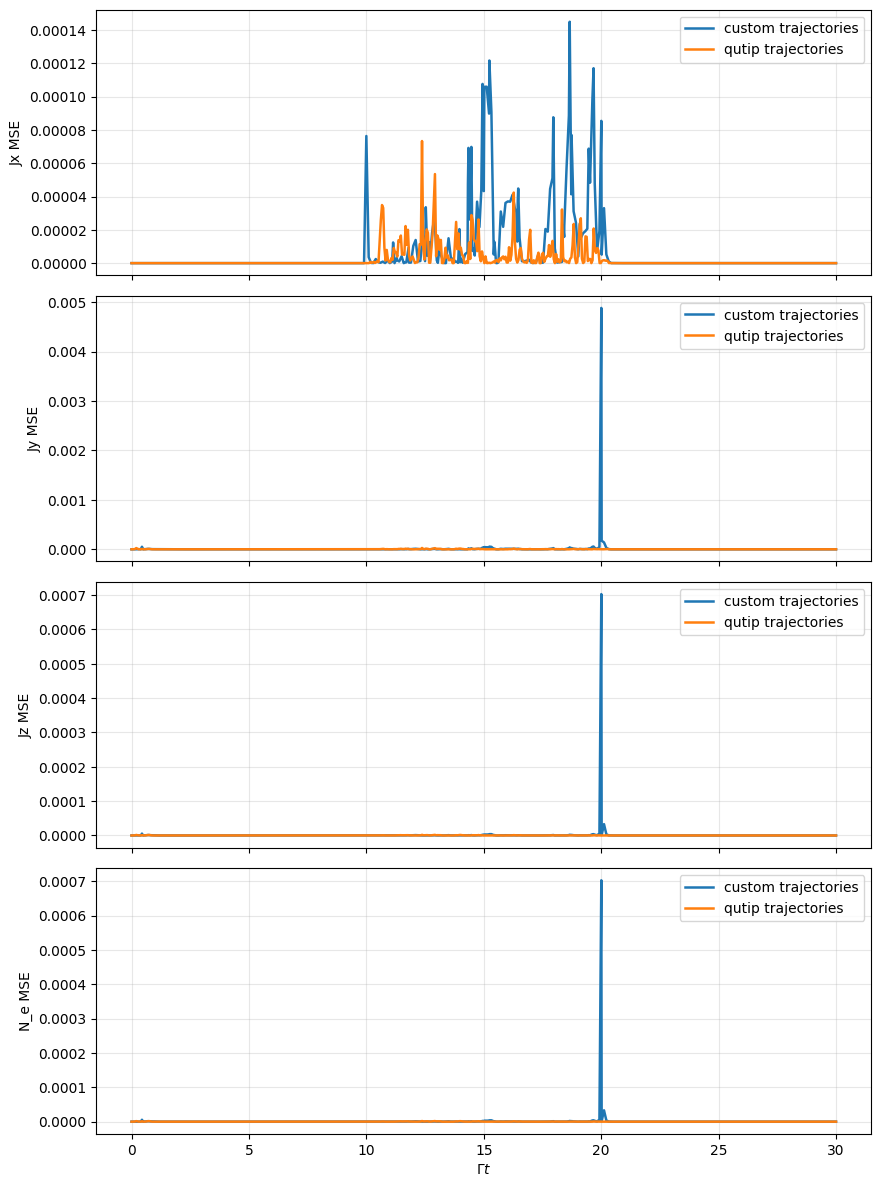

In [8]:
def observable_mse(
    ntraj=10,
    qutip_num_points=600,
    custom_dt=1e-3,
    *,
    run_custom=True,
    run_mcsolve=True,
    run_mesolve=True,
    shifted_jump_operator=False,
):
    import time
    import numpy as np

    from common.plotting import plot_mse_vs_time
    from common.utils import observable_mse_by_time
    from quantum_trajectories_qutip.sim import (
        simulate_fixed_nj_mc_trajectory,
        simulate_fixed_nj_me_trajectory,
    )
    from quantum_trajectories_qutip.aggregator import qutip_fixed_nj_mcsolve_observables
    from quantum_trajectories.aggregator import (
        ensemble_observables,
        make_averaged_result,
    )
    from quantum_trajectories.state_helpers import centered_sector_initial_coeffs
    from quantum_trajectories.ensamble_sim import run_trajectory_ensemble

    keys = ("Jx", "Jy", "Jz", "N_e")
    cache = globals().setdefault("_observable_mse_cache", {})

    phase_signature = tuple(
        (float(p.duration), float(p.omega), float(p.delta), str(p.label))
        for p in phases
    )

    signatures = {
        "custom": (N, gamma, phase_signature, custom_dt, save_every, seed, ntraj, shifted_jump_operator),
        "mcsolve": (N, gamma, phase_signature, qutip_num_points, seed, ntraj, shifted_jump_operator),
        "mesolve": (N, gamma, phase_signature, 10 * qutip_num_points, shifted_jump_operator),
    }

    def get_cached(name, run_now):
        cached = cache.get(name)
        if run_now:
            return None
        if cached is None:
            raise ValueError(
                f"No cached {name} result is available. Rerun with run_{name}=True."
            )
        if cached["signature"] != signatures[name]:
            raise ValueError(
                f"Cached {name} result was built with different parameters. "
                f"Rerun with run_{name}=True."
            )
        return cached["result"], cached.get("runtime_seconds")

    runtimes = {}

    if run_custom:
        sector_coeffs = centered_sector_initial_coeffs(N, half_width=0)
        t0 = time.perf_counter()
        res_ensemble = run_trajectory_ensemble(
            N=N,
            gamma=gamma,
            phases=phases,
            sector_coeffs=sector_coeffs,
            dt=custom_dt,
            save_every=save_every,
            seed=seed,
            ntraj=ntraj,
            shifted_jump_operator=shifted_jump_operator,
        )
        runtimes["custom"] = time.perf_counter() - t0
        obs_custom = make_averaged_result(
            res_ensemble,
            ensemble_observables(res_ensemble),
        )
        cache["custom"] = {
            "signature": signatures["custom"],
            "result": obs_custom,
            "runtime_seconds": runtimes["custom"],
        }
    else:
        obs_custom, runtimes["custom"] = get_cached("custom", run_custom)

    if run_mcsolve:
        t0 = time.perf_counter()
        mc_res = simulate_fixed_nj_mc_trajectory(
            N=N,
            gamma=gamma,
            phases=phases,
            num_points=qutip_num_points,
            ntraj=ntraj,
            seed=seed,
            shifted_jump_operator=shifted_jump_operator,
        )
        runtimes["mcsolve"] = time.perf_counter() - t0
        obs_mc = qutip_fixed_nj_mcsolve_observables(mc_res)
        cache["mcsolve"] = {
            "signature": signatures["mcsolve"],
            "result": obs_mc,
            "runtime_seconds": runtimes["mcsolve"],
        }
    else:
        obs_mc, runtimes["mcsolve"] = get_cached("mcsolve", run_mcsolve)

    if run_mesolve:
        t0 = time.perf_counter()
        me_res = simulate_fixed_nj_me_trajectory(
            N=N,
            gamma=gamma,
            phases=phases,
            num_points=10 * qutip_num_points,
            shifted_jump_operator=shifted_jump_operator,
        )
        runtimes["mesolve"] = time.perf_counter() - t0
        obs_me = qutip_fixed_nj_mcsolve_observables(me_res)
        cache["mesolve"] = {
            "signature": signatures["mesolve"],
            "result": obs_me,
            "runtime_seconds": runtimes["mesolve"],
        }
    else:
        obs_me, runtimes["mesolve"] = get_cached("mesolve", run_mesolve)

    mse_custom = observable_mse_by_time(obs_custom, obs_me, keys=keys)
    mse_mcsolve = observable_mse_by_time(obs_mc, obs_me, keys=keys)

    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)
    plot_mse_vs_time(
        {
            "custom trajectories": mse_custom,
            "qutip trajectories": mse_mcsolve,
        },
        keys=keys,
        output_path=output_dir / "accuracy_qutip_vs_custom.png",
    )

    summary = {}
    for label, mse_data in {
        "custom_vs_mesolve": mse_custom,
        "mcsolve_vs_mesolve": mse_mcsolve,
    }.items():
        out = {
            key: {
                "mean_mse": mse_data[key]["mean_mse"],
                "integrated_mse": mse_data[key]["integrated_mse"],
            }
            for key in keys
        }
        out["score"] = float(np.mean([
            np.sqrt(out["Jx"]["integrated_mse"]),
            np.sqrt(out["Jy"]["integrated_mse"]),
            np.sqrt(out["Jz"]["integrated_mse"]),
            np.sqrt(out["N_e"]["integrated_mse"]),
        ]))
        summary[label] = out

    print(f"MSE custom: {summary['custom_vs_mesolve']['score']}")
    print(f"MSE mcsolve: {summary['mcsolve_vs_mesolve']['score']}")
    print(f"Runtime custom: {runtimes['custom']:.3f} s")
    print(f"Runtime mcsolve: {runtimes['mcsolve']:.3f} s")
    print(f"Runtime mesolve: {runtimes['mesolve']:.3f} s")


# Examples:
observable_mse(ntraj=100, custom_dt=1e-2, run_custom=True, run_mcsolve=True, run_mesolve=True, shifted_jump_operator=False)


Jump count regular jump operator: 75
Jump count shifted jump operator: 4


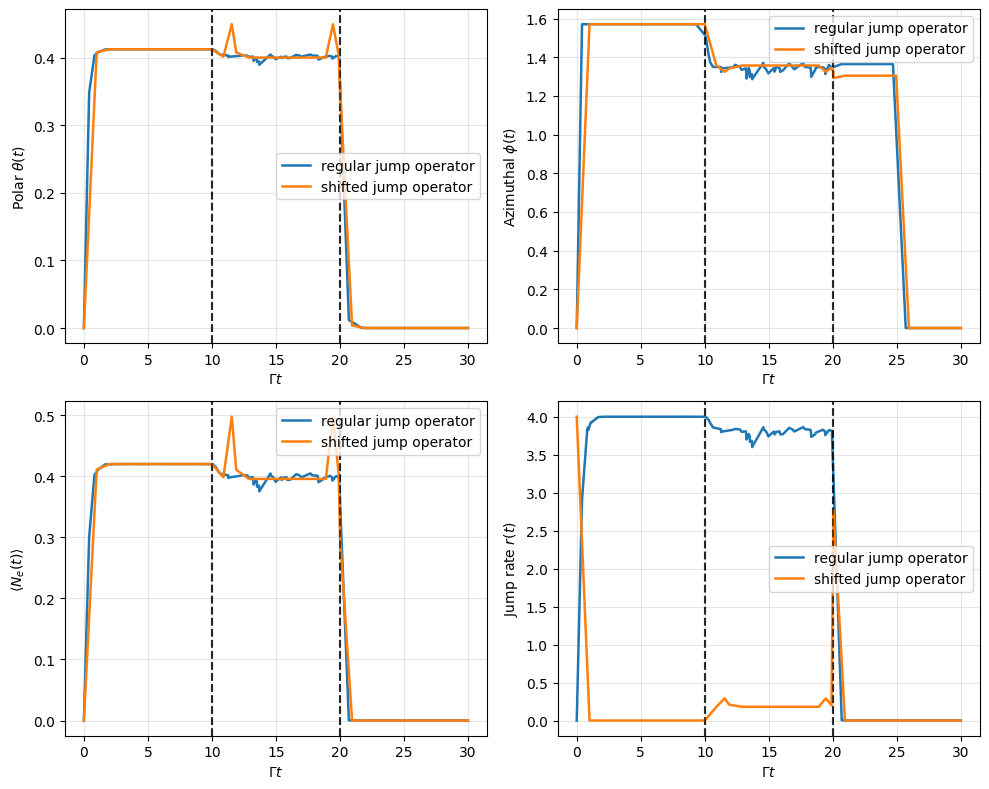

In [ ]:
def compare_shifted_jump_operator_single_trajectory():
    from quantum_trajectories.state_helpers import centered_sector_initial_coeffs
    from quantum_trajectories.sim import simulate_single_trajectory
    from common.plotting import plot_trajectory_angles_and_excitation
    from quantum_trajectories.aggregator import (
        trajectory_observables,
        single_trajectory_to_averaged_result,
    )

    # Returns a dictionary of key: sector Nj, value: coefficient for that sector. 
    sector_coeffs = centered_sector_initial_coeffs(N, half_width=0)

    # Simulate a single trajectory with shifted jump operator
    result_true = simulate_single_trajectory(
        N=N,
        gamma=gamma,
        phases=phases,
        sector_coeffs=sector_coeffs,
        dt=dt,
        save_every=save_every,
        seed=seed,
        shifted_jump_operator=True,
    )
    obs_true = trajectory_observables(result_true)
    obs_true = single_trajectory_to_averaged_result(result_true, obs_true)

    # Simulate a single trajectory without shifted jump operator
    result_false = simulate_single_trajectory(
        N=N,
        gamma=gamma,
        phases=phases,
        sector_coeffs=sector_coeffs,
        dt=dt,
        save_every=save_every,
        seed=seed,
        shifted_jump_operator=False,
    )
    obs_false = trajectory_observables(result_false)
    obs_false = single_trajectory_to_averaged_result(result_false, obs_false)


    # fig, axes = plot_trajectory_angles_and_excitation(result, phases)
    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)
    fig, axes = plot_trajectory_angles_and_excitation(
        obs_false,
        phases,
        label="regular jump operator",
    )
    fig, axes = plot_trajectory_angles_and_excitation(
        obs_true,
        phases,
        axes=axes,
        output_path=output_dir / "shifted_jump_operator.png",
        label="shifted jump operator",
    )

    print(f"Jump count regular jump operator: {result_false.jump_count}")
    print(f"Jump count shifted jump operator: {result_true.jump_count}")

compare_shifted_jump_operator_single_trajectory()

Runtime regular jump operator ensemble: 10.184 s
Runtime shifted jump operator ensemble: 0.526 s


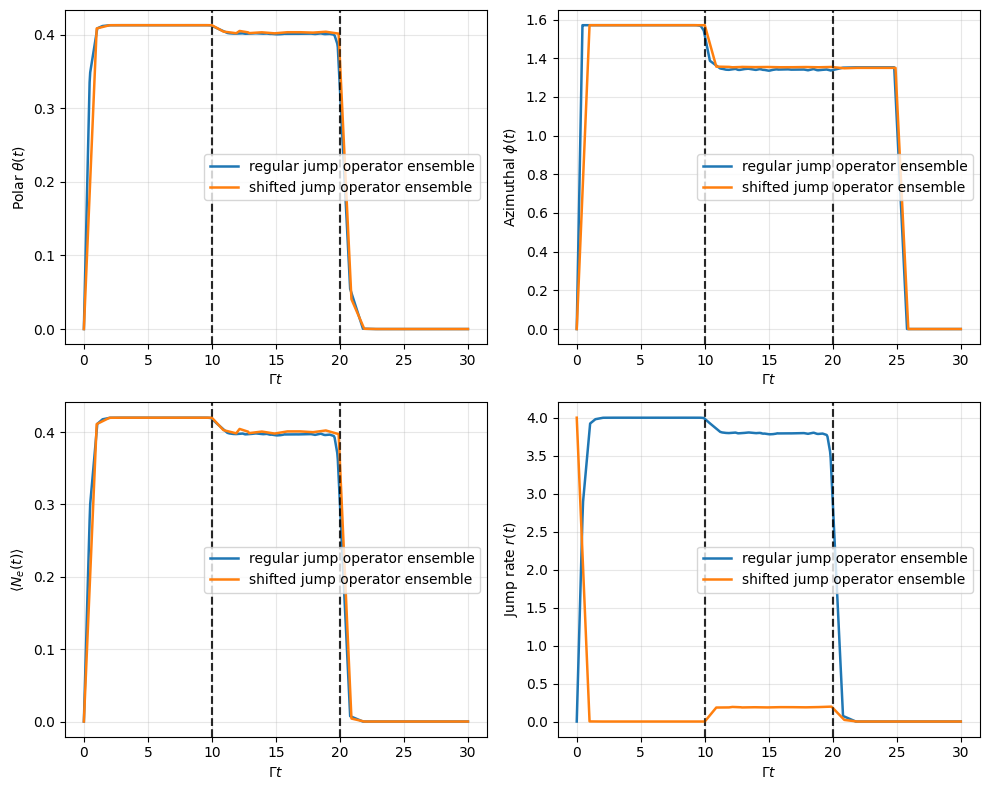

In [10]:
def compare_shifted_jump_operator_ensemble():
    import time
    from quantum_trajectories.state_helpers import centered_sector_initial_coeffs
    from quantum_trajectories.ensamble_sim import run_trajectory_ensemble
    from quantum_trajectories.aggregator import (
        ensemble_observables,
        make_averaged_result,
    )
    from common.plotting import plot_trajectory_angles_and_excitation

    sector_coeffs = centered_sector_initial_coeffs(N, half_width=0)

    t0 = time.perf_counter()
    ensemble_true = run_trajectory_ensemble(
        N=N,
        gamma=gamma,
        phases=phases,
        sector_coeffs=sector_coeffs,
        dt=dt,
        save_every=save_every,
        seed=seed,
        ntraj=100,
        shifted_jump_operator=True,
    )
    runtime_true = time.perf_counter() - t0
    obs_true = make_averaged_result(
        ensemble_true,
        ensemble_observables(ensemble_true),
    )

    t0 = time.perf_counter()
    ensemble_false = run_trajectory_ensemble(
        N=N,
        gamma=gamma,
        phases=phases,
        sector_coeffs=sector_coeffs,
        dt=dt,
        save_every=save_every,
        seed=seed,
        ntraj=100,
        shifted_jump_operator=False,
    )
    runtime_false = time.perf_counter() - t0
    obs_false = make_averaged_result(
        ensemble_false,
        ensemble_observables(ensemble_false),
    )

    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)
    fig, axes = plot_trajectory_angles_and_excitation(
        obs_false,
        phases,
        label="regular jump operator ensemble",
    )
    fig, axes = plot_trajectory_angles_and_excitation(
        obs_true,
        phases,
        axes=axes,
        output_path=output_dir / "shifted_jump_operator_ensemble.png",
        label="shifted jump operator ensemble",
    )

    print(f"Runtime regular jump operator ensemble: {runtime_false:.3f} s")
    print(f"Runtime shifted jump operator ensemble: {runtime_true:.3f} s")

compare_shifted_jump_operator_ensemble()


In [11]:
# from squeezing_parameter import plot_generalized_xi

# %load_ext autoreload
# %autoreload 2

# # Steady state angles
# theta_ss, phi_ss = phase1_ss_angles_for_nj(N_J, Omega0, gamma)

# # tilde_theta, tilde_phi are the phase-1 reference angles used to define |1>
# xi_data, fig, ax = plot_generalized_xi(
#     result,
#     phases,
#     tilde_theta=theta_ss,
#     tilde_phi=phi_ss,
#     output_path="generalized_xi.png",
# )